# Field-Data Inversion: TEM2Go `.xyz` with pyTEM

This notebook takes a raw **TEM Data Manager `.xyz`** export (TEM2Go instrument),
converts it into the exact arrays pyTEM expects, and runs a regularised
Gauss-Newton inversion.

Workflow:
1. Read the file with `read_tem_xyz` (data, waveforms, gate times).
2. Convert a moment (LM/HM) to pyTEM kwargs with `TEMData.to_pytem`.
3. Plot the raw stacked sounding.
4. Define a starting model and invert with `pytem.invert` (waveform convolution).
5. Inspect the recovered model, data fit, and convergence.

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make the workspace root importable so both `read_tem_xyz` and `pytem` resolve.
ROOT = r'C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects\Python\pyTEM'
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from read_tem_xyz import read_tem_xyz
from pytem import invert, fwd_square_offset, convolve_waveform
from pytem.plotter import plot_inversion

## 1. Read the file and convert to pyTEM format

`to_pytem` returns the gate centre `times`, the stacked `obs_data` (dB/dt in
V/m^2 = T/s), the fractional `noise_std`, the transmitter waveform in absolute
ampere-turns, and the loop geometry (square, offset receiver).

In [2]:
XYZ = r'C:\Users\pamcl\Downloads\2026_0701_165727_ChA.xyz'
MOMENT = 'HM'   # 'HM' has 23 gates (deeper); 'LM' has 7 early-time gates.

tem = read_tem_xyz(XYZ)
kw = tem.to_pytem(MOMENT)

times     = kw['times']
obs_data  = kw['obs_data']
noise_std = kw['noise_std']
wf_t      = kw['waveform_times']
wf_I      = kw['waveform_currents']
tx_side   = kw['tx_size']
rx_x, rx_y = kw['rx_x'], kw['rx_y']

print(f"Instrument : {tem.meta.get('InstrumentType')} ({tem.meta.get('InstrumentID')})")
print(f"Moment     : {MOMENT}  ({kw['n_records']} records stacked)")
print(f"Geometry   : {kw['geometry']}  tx_side={tx_side} m, {kw['tx_turns']} turns, "
      f"peak I={kw['peak_current']} A, Rx=({rx_x}, {rx_y}) m")
print(f"Gates      : {times.size}  [{times[0]:.2e} .. {times[-1]:.2e}] s")

Instrument : TEM2Go (temc-001)
Moment     : HM  (81 records stacked)
Geometry   : square_offset  tx_side=3.0 m, 4 turns, peak I=20.0 A, Rx=(-13.0, 0.0) m
Gates      : 23  [2.52e-05 .. 3.94e-03] s


## 2. Raw stacked sounding

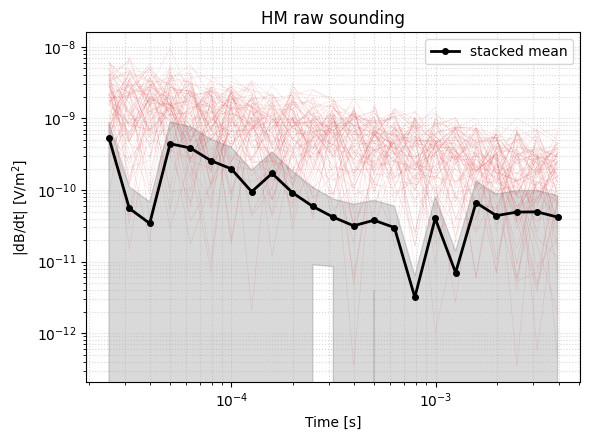

In [3]:
dbdt_all = tem.dbdt(MOMENT)   # (n_records, n_gates)

fig, ax = plt.subplots(figsize=(6, 4.5))
for row in dbdt_all:
    ax.loglog(times, np.abs(row), color='tab:red', lw=0.4, alpha=0.15)
ax.loglog(times, obs_data, 'ko-', ms=4, lw=2, label='stacked mean')
band = obs_data * np.clip(noise_std, 0, 1)
ax.fill_between(times, obs_data - band, obs_data + band, color='k', alpha=0.15)
ax.set_xlabel('Time [s]')
ax.set_ylabel('|dB/dt| [V/m$^2$]')
ax.set_title(f'{MOMENT} raw sounding')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Data-quality check (SNR)

Before inverting, check the per-gate signal-to-noise ratio, estimated from the scatter across the stacked records. Gates with **SNR < ~3** carry little real signal; a coherent sounding decays smoothly without sign flips.

> Note: the example file `2026_0701_165727_ChA.xyz` is a background / low-signal recording. Its SNR stays below ~2 at every gate with random sign flips, so it cannot be inverted for a meaningful model. Point `XYZ` at a real sounding to get useful results; the workflow below is unchanged.

In [6]:
t, mean, sem, snr = tem.snr(MOMENT)
good = snr >= 3.0
print(f'Gates with SNR >= 3: {good.sum()} / {snr.size}')
for i in range(snr.size):
    flag = 'ok' if good[i] else '--'
    print(f'  g{i+1:2d}  t={t[i]:.2e}s  mean={mean[i]:+.2e}  SNR={snr[i]:5.1f}  {flag}')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogx(t, snr, 'o-')
ax.axhline(3.0, color='r', ls='--', lw=1, label='SNR = 3')
ax.set_xlabel('Time [s]'); ax.set_ylabel('SNR [-]')
ax.set_title(f'{MOMENT} per-gate SNR'); ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(); plt.tight_layout(); plt.show()

AttributeError: 'TEMData' object has no attribute 'snr'

## 4. Starting model

A multi-layer model with fixed, log-spaced thicknesses (a "smooth" parametrisation) started from a homogeneous half-space. The inversion recovers the resistivity of each layer under a smoothness (roughness) constraint.

In [4]:
n_layers   = 15
thicknesses = np.logspace(np.log10(2.0), np.log10(15.0), n_layers - 1)  # (n_layers-1,) [m]
rho_start  = 50.0                                                        # half-space [Ohm.m]
log_resistivities = np.log(np.full(n_layers, rho_start))

print(f'{n_layers} layers, total depth {thicknesses.sum():.1f} m, start rho = {rho_start} Ohm.m')

15 layers, total depth 92.5 m, start rho = 50.0 Ohm.m


## 5. Invert

The transmitter waveform is passed via `waveform_times` / `waveform_currents`, so pyTEM convolves the step-off response with the finite current ramp. The square loop with an offset receiver selects the `square_offset` geometry.

In [5]:
result = invert(
    obs_data=obs_data,
    thicknesses=thicknesses,
    log_resistivities=log_resistivities,
    tx_size=tx_side,
    times=times,
    noise_std=noise_std,
    maxit=15,
    transform='euler',
    analytical_j=False,
    geometry=kw['geometry'],
    rx_x=rx_x, rx_y=rx_y,
    waveform_times=wf_t,
    waveform_currents=wf_I,
    waveform_n_quad=5,
)

best_rho = result['resistivities']
rms_hist = result['rms_history']
rho_hist = [np.exp(m) for m in result['model_history']]
print(f"Final RMS = {rms_hist[-1]:.3f} after {result['n_iter']} iterations")
print('Recovered resistivities [Ohm.m]:')
print(np.array2string(best_rho, precision=1))

Observed data: Mean Apparent Resistivity = 747.4 Ohm.m (over 23/23 valid gates)
Alpha start = 0.000
Iteration   1:  RMS = 0.00
  RMS <= 1 - converged.
Final RMS = 0.000 after 1 iterations
Recovered resistivities [Ohm.m]:
[50. 50. 50. 50. 50. 50. 50. 50. 50. 50. 50. 50. 50. 50. 50.]


## 6. Results: data fit, convergence, and recovered model

In [ ]:
# Modelled response of the best-fit model: step-off response (unit current)
# convolved with the same transmitter waveform.
step_t = np.logspace(np.log10(times.min() * 1e-2), np.log10(times.max() * 2.0), 300)
step_r = fwd_square_offset(
    thicknesses, best_rho, tx_side, rx_x, rx_y, step_t,
    current=1.0, signal=-1, transform='euler', rx_turns=1,
)
mod_data = np.abs(convolve_waveform(step_t, step_r, wf_t, wf_I, times))

plot_inversion(
    times=times,
    obs_data=obs_data,
    mod_data=mod_data,
    thicknesses=thicknesses,
    best_rho=best_rho,
    iter_rms_list=rms_hist,
    rho_hist=rho_hist,
    noise=noise_std,
)
plt.show()